# Export Sentinel 2 Data - Geographic Image Data 12 Band

## About this Notebook

### Objective

Extract Sentinel-2 (S2) image chips around ground sensor locations to generate structured image inputs for the multimodal fusion model.

This notebook creates geospatially aligned image patches that correspond to each sensor and time period used in the modeling pipeline.

---

### Inputs

- Cleaned ground sensor dataset (from `ExportSensorData`)
- Sentinel-2 imagery (12-band surface reflectance data)
- Sensor latitude and longitude coordinates
- Temporal configuration (e.g., quarterly aggregation window)

Data location:
`gs://msads-mba-capstone-team-1/Data/`

---

### Outputs

- One Sentinel-2 image chip per sensor per time period
- All 12 spectral bands preserved
- Consistent spatial dimensions (e.g., 120x120 or 121x121 pixels)
- Exported image files saved to GCS

Example output path:
`gs://msads-mba-capstone-team-1/Data/S2_images/`

These image chips are later used as the image input branch in the fusion model.

---

### Workflow Overview

1. Load cleaned ground sensor dataset  
2. Loop over each sensor and time period  
3. Query and extract Sentinel-2 imagery for the matching date range  
4. Clip imagery to a fixed buffer around sensor coordinates  
5. Export multi-band raster image chips to GCS  

---

### Key Notes

- Image chip size must remain consistent for model compatibility.
- Coordinate reference system (CRS) must be handled correctly during clipping.
- All 12 Sentinel-2 bands should be preserved in the exported rasters.
- Temporal alignment must match the aggregation used in the ground sensor dataset.
- Missing or corrupted images should be logged and handled explicitly.

---

### Position in Pipeline

Pipeline position:

Ground Sensor NO₂ → ExportSensorData → ExportS2SensorData → FusionNO2Model

This notebook provides the Sentinel-2 image modality for multimodal training.

## Configuration

In [7]:
# Config
ee_project_name = "msads-mba-autumn-2025-team-1"
sensor_path = "gs://msads-mba-capstone-team-1/Data/TrainingData/sensor_data_clean.csv"
bucket_name = "msads-mba-capstone-team-1"
gcs_folder = "Data/S2_images"

## Export S2 Images around Sensors

In [8]:
# Imports
import pandas as pd

In [9]:
sensor_data = pd.read_csv(
    sensor_path
)

In [10]:
len(sensor_data)

679

In [11]:
sensor_data.head()

,DeviceId,Latitude,Longitude,quarter,no2_mean,pm25_mean,o3_mean,num_days,q_start,q_end,no2_log
0,2004,41.8451,-87.695204,2021Q3,9.837126,13.072161,32.996590,92,2021-07-01,2021-09-30,2.382978
1,2004,41.8451,-87.695204,2021Q4,13.889216,10.791195,20.117447,92,2021-10-01,2021-12-31,2.700637
2,2004,41.8451,-87.695204,2022Q1,12.688283,9.802504,18.686535,76,2022-01-01,2022-03-31,2.616540
3,2004,41.8451,-87.695204,2022Q2,10.932224,10.035338,30.087279,91,2022-04-01,2022-06-30,2.479243
4,2004,41.8451,-87.695204,2022Q3,9.139607,10.753448,32.074869,92,2022-07-01,2022-09-30,2.316449


In [12]:
import ee
import time
import pandas as pd

ee.Initialize(project=ee_project_name)

# -------------------------------------------------
# SENTINEL-2 COLLECTION
# -------------------------------------------------
S2_COLLECTION = "COPERNICUS/S2_SR_HARMONIZED"

S2_BANDS = [
    "B1", "B2", "B3", "B4",
    "B5", "B6", "B7", "B8",
    "B8A", "B9", "B11", "B12"
]

# -------------------------------------------------
# UPSCALE ALL BANDS TO 10m
# -------------------------------------------------
def resample_to_10m(image):
    return image.resample("bilinear").reproject(
        crs="EPSG:32616",
        scale=10
    )

# -------------------------------------------------
# CREATE 1.2km CHIP
# -------------------------------------------------
def create_chip(image, lat, lon):
    point = ee.Geometry.Point([lon, lat])
    
    # Transform to UTM (meters)
    point_utm = point.transform("EPSG:32616", 1)
    coords = point_utm.coordinates()
    
    x = ee.Number(coords.get(0))
    y = ee.Number(coords.get(1))
    
    half_size = 600  # meters
    
    # Create exact 1200m × 1200m square
    region = ee.Geometry.Rectangle([
        x.subtract(half_size),
        y.subtract(half_size),
        x.add(half_size),
        y.add(half_size)
    ], "EPSG:32616", False)
    
    chip = image.clip(region)
    
    return chip, region


# -------------------------------------------------
# Cloud Cover or Quarterly Composite
# -------------------------------------------------
def get_best_s2_image(start_date, end_date, lat, lon):
    point = ee.Geometry.Point([lon, lat])
    
    # Full quarterly collection
    full_collection = (
        ee.ImageCollection(S2_COLLECTION)
        .filterBounds(point)
        .filterDate(start_date, end_date)
    )
    
    # Try strict cloud filter (<20%)
    filtered_collection = full_collection.filter(
        ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20)
    )
    
    filtered_size = filtered_collection.size()
    full_size = full_collection.size()
    
    # Logic:
    # If filtered exists → use least cloudy scene
    # Else if full collection exists → use quarterly median
    # Else → return None
    
    image = ee.Algorithms.If(
        filtered_size.gt(0),
        filtered_collection.sort("CLOUDY_PIXEL_PERCENTAGE").first(),
        ee.Algorithms.If(
            full_size.gt(0),
            full_collection.median(),
            None
        )
    )
    
    return ee.Image(image)

# -------------------------------------------------
# ACTIVE TASK CHECKER
# -------------------------------------------------
def wait_for_available_slot(max_active):
    while True:
        active_tasks = [
            t for t in ee.batch.Task.list()
            if t.status()["state"] in ["READY", "RUNNING"]
        ]
        if len(active_tasks) < max_active:
            break
        print(f"Waiting... {len(active_tasks)} active tasks")
        time.sleep(30)

In [13]:
# -------------------------------------------------
# CONFIG
# -------------------------------------------------
start_index = 1          # e.g. 100
end_index = 1            # e.g. 200

target_year = None#2022          # set to None to ignore
target_quarter = None#"Q1"       # set to None to ignore

target_devices = None       # e.g. [2002, 2005, 2010] or None

max_active_tasks = 5

# -------------------------------------------------
# FILTER DATAFRAME BASED ON CONFIG
# -------------------------------------------------

df_to_export = sensor_data.copy()

# Filter by specific devices
if target_devices is not None:
    target_devices = set(str(d) for d in target_devices)
    df_to_export = df_to_export[
        df_to_export["DeviceId"].astype(str).isin(target_devices)
    ]

# Filter by year
if target_year is not None:
    df_to_export = df_to_export[
        df_to_export["quarter"].str.startswith(str(target_year))
    ]

# Filter by quarter
if target_quarter is not None:
    df_to_export = df_to_export[
        df_to_export["quarter"].str.endswith(target_quarter)
    ]

# Apply index slicing
if start_index is not None and end_index is not None:
    df_to_export = df_to_export.iloc[start_index:end_index]

df_to_export = df_to_export.reset_index(drop=True)

print("Total rows to export:", len(df_to_export))

# -------------------------------------------------
# ACTIVE TASK CHECKER
# -------------------------------------------------
def wait_for_available_slot(max_active):
    while True:
        active_tasks = [
            t for t in ee.batch.Task.list()
            if t.status()["state"] in ["READY", "RUNNING"]
        ]
        if len(active_tasks) < max_active:
            break
        print(f"Waiting... {len(active_tasks)} active tasks")
        time.sleep(30)

# -------------------------------------------------
# EXPORT LOOP
# -------------------------------------------------

for _, row in df_to_export.iterrows():

    device_id = str(row["DeviceId"])
    quarter = str(row["quarter"])
    lat = float(row["Latitude"])
    lon = float(row["Longitude"])
    start_date = pd.to_datetime(row["q_start"]).strftime("%Y-%m-%d")
    end_date = pd.to_datetime(row["q_end"]).strftime("%Y-%m-%d")
    
    print(f"Processing Device {device_id} | {quarter}")
    
    image = get_best_s2_image(start_date, end_date, lat, lon)
    
    if image is None:
        print("No Sentinel-2 image available — skipping.")
        continue
    
    image = image.select(S2_BANDS)
    image = resample_to_10m(image)
    
    chip, region = create_chip(image, lat, lon)
    
    file_name = f"S2_Device{device_id}_{quarter}"
    
    wait_for_available_slot(max_active_tasks)
    
    task = ee.batch.Export.image.toCloudStorage(
        image=chip,
        description=file_name,
        bucket=bucket_name,
        fileNamePrefix=f"{gcs_folder}/{file_name}",
        region=region,
        dimensions="120x120",
        fileFormat="GeoTIFF",
        maxPixels=1e13
    )
    
    task.start()
    print(f"Export started: {file_name}")

print("Export job submission complete.")

Total rows to export: 0
Export job submission complete.


## Data Checks

In [14]:
# Identify missing files
from google.cloud import storage
import pandas as pd

# -----------------------------
# 1. Get expected sensor-quarter pairs
# -----------------------------
expected_pairs = (
    sensor_data[["DeviceId", "quarter"]]
    .drop_duplicates()
    .copy()
)

# Make a filename column that matches your export naming
expected_pairs["filename"] = (
    "S2_Device"
    + expected_pairs["DeviceId"].astype(str)
    + "_"
    + expected_pairs["quarter"].astype(str)
    + ".tif"
)

expected_set = set(expected_pairs["filename"])

# -----------------------------
# 2. Get existing files in GCS
# -----------------------------
prefix = "Data/S2_images/"

client = storage.Client()
blobs = client.list_blobs(bucket_name, prefix=prefix)

existing_files = set()

for blob in blobs:
    name = blob.name.split("/")[-1]
    if name.endswith(".tif"):
        existing_files.add(name)

# -----------------------------
# 3. Compare
# -----------------------------
missing_files = expected_set - existing_files

missing_df = expected_pairs[
    expected_pairs["filename"].isin(missing_files)
][["DeviceId", "quarter"]]

print(f"Total expected pairs: {len(expected_set)}")
print(f"Total existing files: {len(existing_files)}")
print(f"Missing S2 files: {len(missing_files)}")

missing_df.head()

Total expected pairs: 679
Total existing files: 847
Missing S2 files: 0


,DeviceId,quarter


In [15]:
#Check files are non-zero
small_files = []

for blob in client.list_blobs(bucket_name, prefix=prefix):
    name = blob.name.split("/")[-1]
    if name in expected_set:
        if blob.size < 100000:  # threshold ~100KB
            small_files.append(name)

print("Potentially bad files:", small_files)

Potentially bad files: []


In [16]:
len(small_files)

0

In [17]:
# Check Image
import gcsfs
import rasterio
from rasterio.io import MemoryFile

fs = gcsfs.GCSFileSystem()

path = "msads-mba-capstone-team-1/Data/S2_images/S2_Device2002_2022Q1.tif"

with fs.open(path, "rb") as f:
    with MemoryFile(f.read()) as memfile:
        with memfile.open() as src:
            print("Width:", src.width)
            print("Height:", src.height)
            print("Band count:", src.count)
            print("CRS:", src.crs)
            print("Min:", src.read().min())
            print("Max:", src.read().max())
            print(src.res)
            print(src.count)


Width: 120
Height: 120
Band count: 12
CRS: EPSG:32616
Min: 140
Max: 9584
(10.0, 10.0)
12


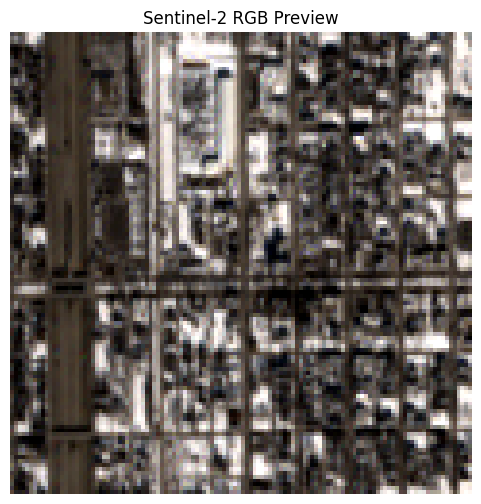

In [18]:
import numpy as np
import matplotlib.pyplot as plt

with fs.open(path, "rb") as f:
    with MemoryFile(f.read()) as memfile:
        with memfile.open() as src:
            
            # Read bands
            red = src.read(4)   # B4
            green = src.read(3) # B3
            blue = src.read(2)  # B2

# Stack into RGB
rgb = np.stack([red, green, blue], axis=-1)

# Normalize for display (clip 1–99 percentile for contrast)
p2, p98 = np.percentile(rgb, (1, 99))
rgb_display = np.clip((rgb - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(6,6))
plt.imshow(rgb_display)
plt.axis("off")
plt.title("Sentinel-2 RGB Preview")
plt.show()


In [19]:
# Check Corrupted IMages
import gcsfs
import rasterio
import numpy as np
import pandas as pd
from tqdm import tqdm

fs = gcsfs.GCSFileSystem()

bucket_path = "msads-mba-capstone-team-1/Data/S2_images/"
files = [f for f in fs.ls(bucket_path) if f.endswith(".tif")]

results = []
bad_files = []

for file_path in tqdm(files):
    try:
        with fs.open(file_path, 'rb') as f:
            with rasterio.open(f) as src:
                data = src.read()

        all_zero_mask = np.all(data == 0, axis=0)
        percent_zero = np.mean(all_zero_mask) * 100

        results.append({
            "file": file_path.split("/")[-1],
            "percent_zero_pixels": percent_zero
        })

    except Exception as e:
        bad_files.append(file_path.split("/")[-1])
        continue

df_mask = pd.DataFrame(results)

print("\n===== SUMMARY =====")
print(df_mask["percent_zero_pixels"].describe())

print("\n===== TOP 10 MOST MASKED =====")
print(df_mask.sort_values("percent_zero_pixels", ascending=False).head(10))

print("\n===== FILES > 40% MASKED =====")
extreme = df_mask[df_mask["percent_zero_pixels"] > 40]
print(len(extreme))

print("\n===== CORRUPTED FILES =====")
print(len(bad_files))

100%|██████████| 847/847 [01:11<00:00, 11.79it/s]



===== SUMMARY =====
count    847.000000
mean       0.073150
std        1.546232
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       38.319444
Name: percent_zero_pixels, dtype: float64

===== TOP 10 MOST MASKED =====
                         file  percent_zero_pixels
812  S2_Device2209_2022Q1.tif            38.319444
243  S2_Device2064_2022Q1.tif            23.638889
557  S2_Device2120_2022Q1.tif             0.000000
558  S2_Device2120_2022Q2.tif             0.000000
559  S2_Device2120_2022Q3.tif             0.000000
560  S2_Device2120_2022Q4.tif             0.000000
561  S2_Device2120_2023Q1.tif             0.000000
562  S2_Device2121_2021Q3.tif             0.000000
563  S2_Device2121_2021Q4.tif             0.000000
564  S2_Device2121_2022Q1.tif             0.000000

===== FILES > 40% MASKED =====
0

===== CORRUPTED FILES =====
0


In [20]:
print(bad_files[:20])

[]


In [21]:
# Combine both sources
bad_set = set(bad_files)

if 'file' in extreme.columns:
    extreme_set = set(extreme['file'].tolist())
else:
    extreme_set = set()

corrupt_files = bad_set.union(extreme_set)

print("Total corrupted files to re-export:", len(corrupt_files))
corrupt_pairs = []

for fname in corrupt_files:
    name = fname.replace(".tif", "")
    parts = name.split("_")
    
    device_id = parts[1].replace("Device", "")
    quarter = parts[2]
    
    # Only re-export 2022Q1
    if quarter == "2022Q1":
        corrupt_pairs.append((device_id, quarter))

corrupt_pairs = set(corrupt_pairs)

print("2022Q1 files to re-export:", len(corrupt_pairs))


Total corrupted files to re-export: 0
2022Q1 files to re-export: 0


In [22]:
rows_to_export = sensor_data[
    sensor_data.apply(
        lambda row: (str(row["DeviceId"]), str(row["quarter"])) in corrupt_pairs,
        axis=1
    )
].copy()

print("Matching rows found:", len(rows_to_export))

Matching rows found: 0


In [23]:
# Build set of valid filenames from rows_to_export

valid_files = set()

for _, row in rows_to_export.iterrows():
    device_id = str(row["DeviceId"])
    quarter = str(row["quarter"])
    fname = f"S2_Device{device_id}_{quarter}.tif"
    valid_files.add(fname)

# Orphan corrupted files
orphan_files = corrupt_files - valid_files

print("Orphan corrupted files (not in sensor_data):", len(orphan_files))
print(orphan_files)


Orphan corrupted files (not in sensor_data): 0
set()


In [24]:
import gcsfs

fs = gcsfs.GCSFileSystem()

bucket_prefix = "msads-mba-capstone-team-1/Data/S2_images"

for fname in orphan_files:
    file_path = f"{bucket_prefix}/{fname}"
    
    if fs.exists(file_path):
        fs.rm(file_path)
        print(f"Deleted: {fname}")
    else:
        print(f"File not found (already removed?): {fname}")

print("Orphan corrupted files removed.")


Orphan corrupted files removed.
